In [2]:
# Cell 1: Imports and setup
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter

# Set plot style
sns.set_style("darkgrid")

# Path to dataset
DATA_DIR = Path("../data/raw/archive")
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

print("Directories found:")
print(f"  Training: {list(TRAIN_DIR.iterdir())}")
print(f"  Testing:  {list(TEST_DIR.iterdir())}")

Directories found:
  Training: [WindowsPath('../data/raw/archive/Training/glioma'), WindowsPath('../data/raw/archive/Training/meningioma'), WindowsPath('../data/raw/archive/Training/notumor'), WindowsPath('../data/raw/archive/Training/pituitary')]
  Testing:  [WindowsPath('../data/raw/archive/Testing/glioma'), WindowsPath('../data/raw/archive/Testing/meningioma'), WindowsPath('../data/raw/archive/Testing/notumor'), WindowsPath('../data/raw/archive/Testing/pituitary')]


In [3]:
# Cell 2: Count images per class
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

for split_name, split_dir in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    print(f"\n{split_name}:")
    total = 0
    for cls in CLASSES:
        count = len(list((split_dir / cls).iterdir()))
        total += count
        print(f"  {cls:15s} → {count} images")
    print(f"  {'TOTAL':15s} → {total} images")

DATASET OVERVIEW

Training:
  glioma          → 1400 images
  meningioma      → 1400 images
  notumor         → 1400 images
  pituitary       → 1400 images
  TOTAL           → 5600 images

Testing:
  glioma          → 400 images
  meningioma      → 400 images
  notumor         → 400 images
  pituitary       → 400 images
  TOTAL           → 1600 images


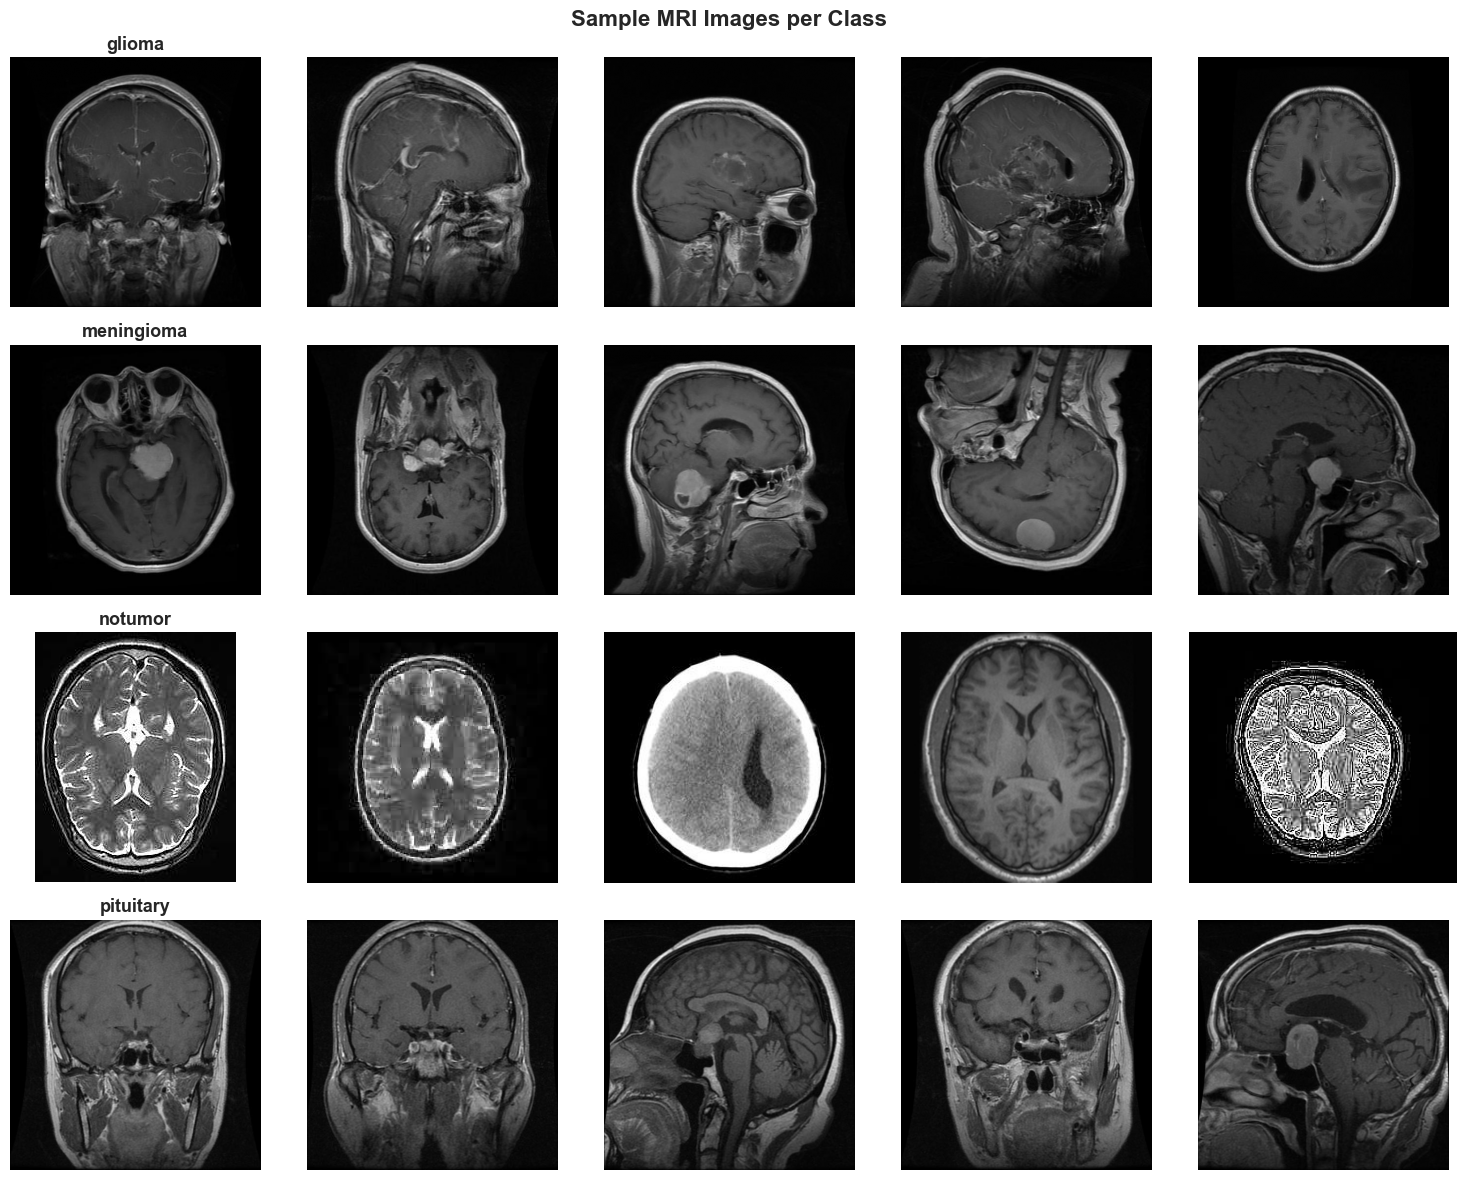

Saved to outputs/figures/sample_images.png


In [4]:
# Cell 3: Visualize sample images from each class
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle("Sample MRI Images per Class", fontsize=16, fontweight="bold")

for row, cls in enumerate(CLASSES):
    cls_dir = TRAIN_DIR / cls
    images = list(cls_dir.iterdir())[:5]  # First 5 images
    
    for col, img_path in enumerate(images):
        img = Image.open(img_path)
        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].axis("off")
        
        if col == 0:
            axes[row][col].set_title(cls, fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/sample_images.png")

In [5]:
# Cell 4: Check image sizes and formats
widths = []
heights = []
modes = []
problematic = []

for cls in CLASSES:
    cls_dir = TRAIN_DIR / cls
    for img_path in cls_dir.iterdir():
        try:
            img = Image.open(img_path)
            widths.append(img.size[0])
            heights.append(img.size[1])
            modes.append(img.mode)
        except Exception as e:
            problematic.append((img_path, str(e)))

print("=" * 50)
print("IMAGE PROPERTIES")
print("=" * 50)
print(f"\nWidth  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"\nImage modes: {Counter(modes)}")
print(f"Corrupted images: {len(problematic)}")

if problematic:
    print("\nProblematic files:")
    for path, error in problematic:
        print(f"  {path} → {error}")

IMAGE PROPERTIES

Width  — min: 150, max: 1375, mean: 459
Height — min: 168, max: 1446, mean: 462

Image modes: Counter({'RGB': 3238, 'L': 2358, 'RGBA': 3, 'P': 1})
Corrupted images: 0


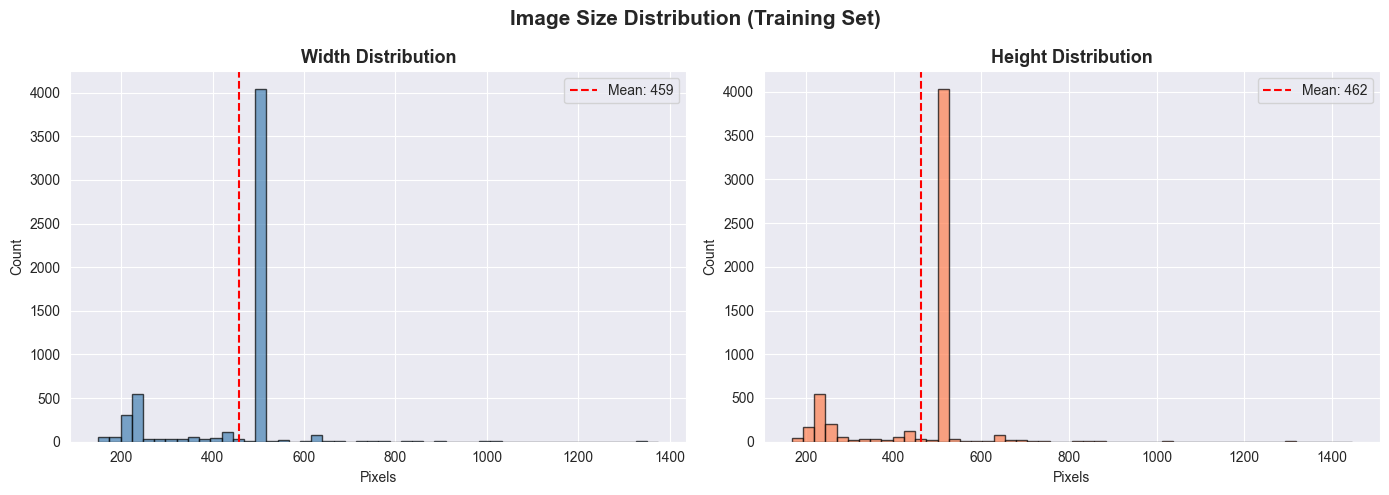

In [6]:
# Cell 5: Image size distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Width Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Pixels")
axes[0].set_ylabel("Count")
axes[0].axvline(np.mean(widths), color="red", linestyle="--", label=f"Mean: {np.mean(widths):.0f}")
axes[0].legend()

axes[1].hist(heights, bins=50, color="coral", edgecolor="black", alpha=0.7)
axes[1].set_title("Height Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Pixels")
axes[1].set_ylabel("Count")
axes[1].axvline(np.mean(heights), color="red", linestyle="--", label=f"Mean: {np.mean(heights):.0f}")
axes[1].legend()

plt.suptitle("Image Size Distribution (Training Set)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

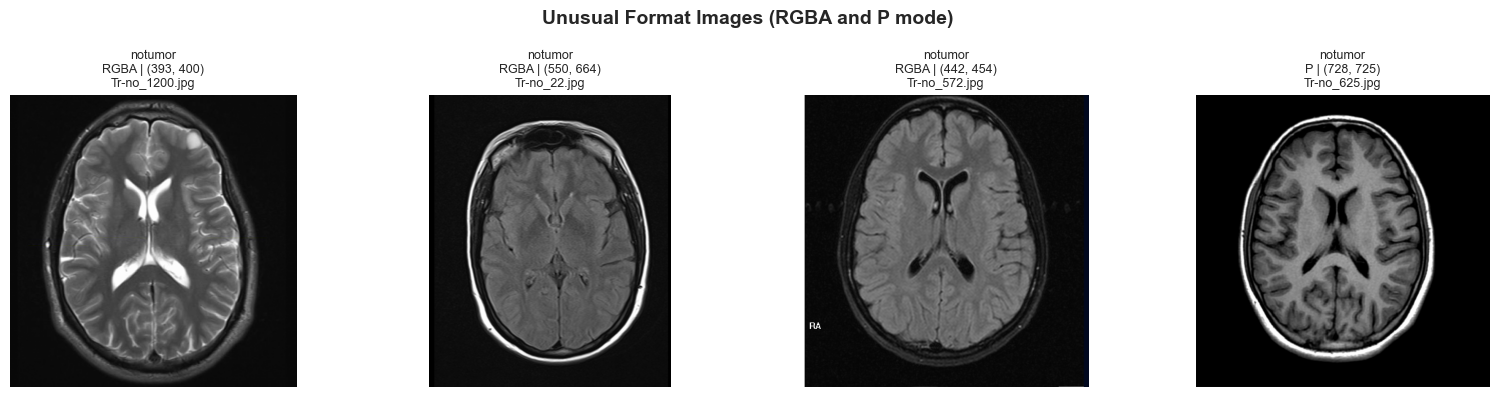

In [7]:
# Cell 6: Find and display unusual format images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Unusual Format Images (RGBA and P mode)", fontsize=14, fontweight="bold")

idx = 0
for cls in CLASSES:
    cls_dir = TRAIN_DIR / cls
    for img_path in cls_dir.iterdir():
        img = Image.open(img_path)
        if img.mode in ["RGBA", "P"]:
            axes[idx].imshow(img)
            axes[idx].set_title(f"{cls}\n{img.mode} | {img.size}\n{img_path.name}", fontsize=9)
            axes[idx].axis("off")
            idx += 1
            if idx >= 4:
                break
    if idx >= 4:
        break

plt.tight_layout()
plt.savefig("../outputs/figures/unusual_images.png", dpi=150, bbox_inches="tight")
plt.show()

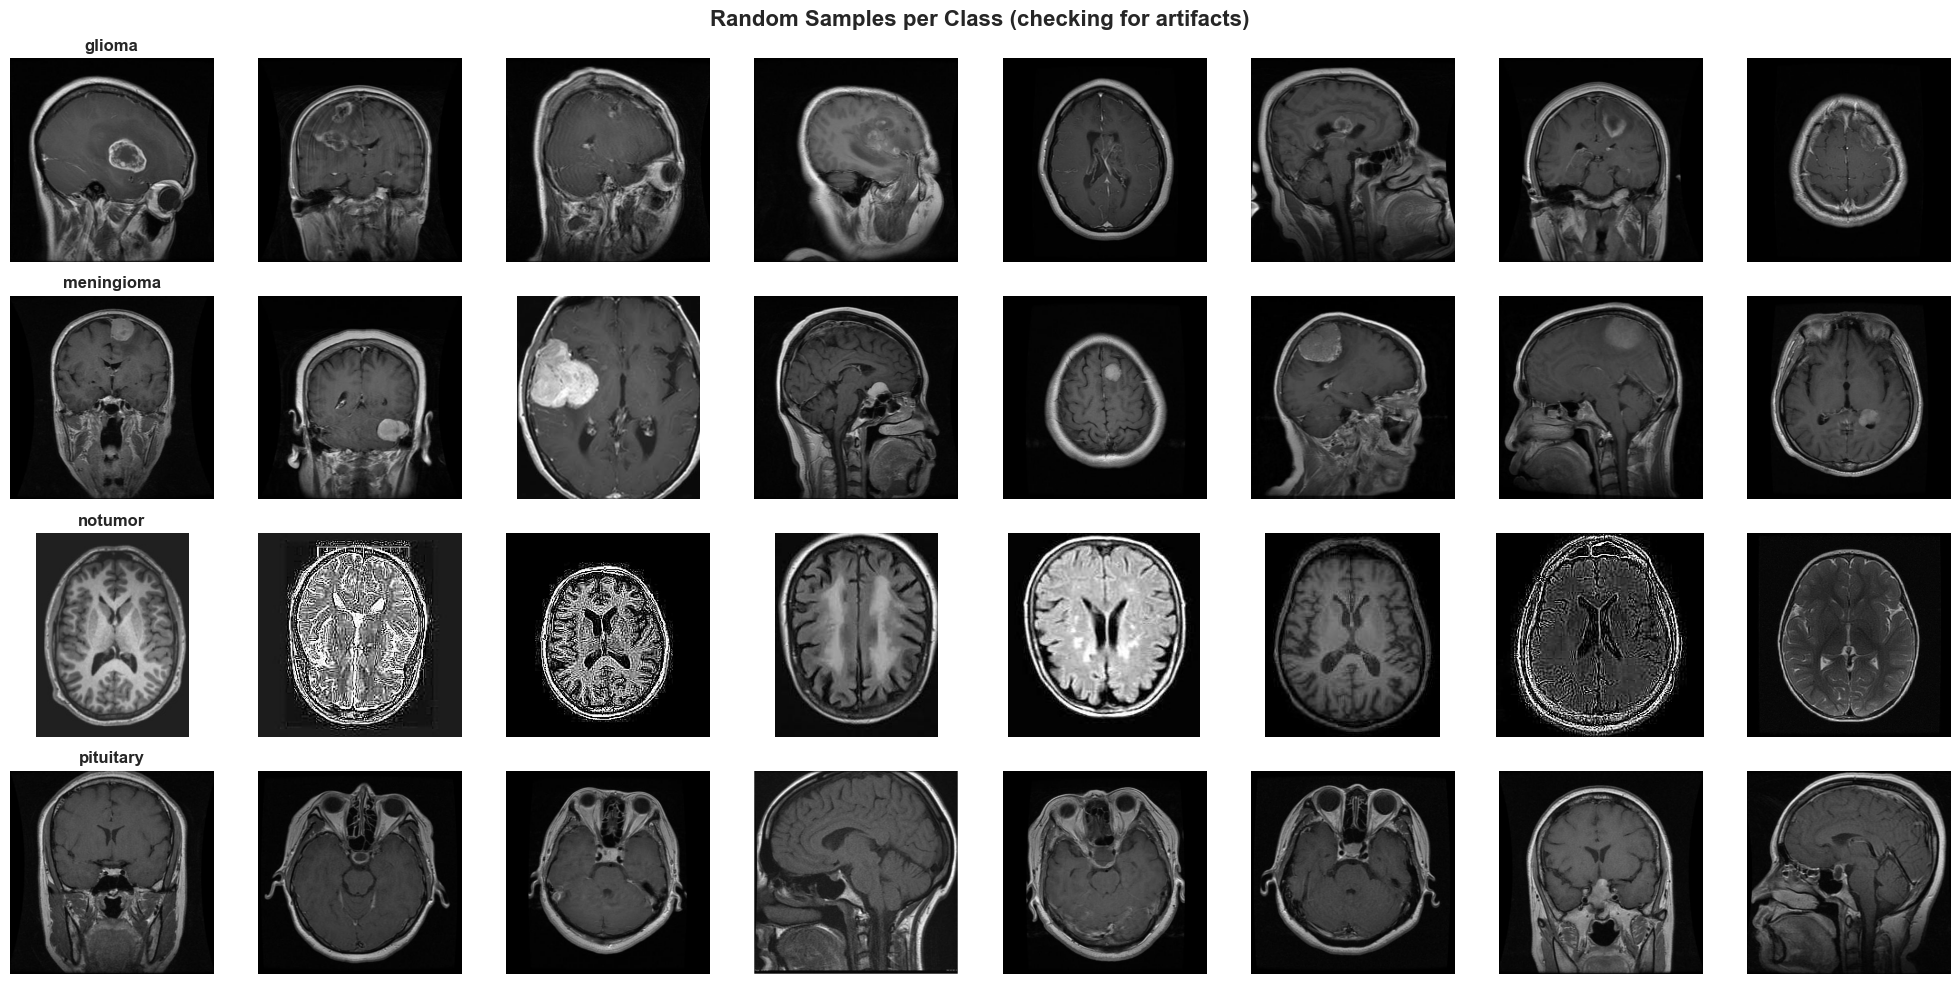

In [8]:
# Cell 7: Display random samples to check for annotations/artifacts
import random
random.seed(42)

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle("Random Samples per Class (checking for artifacts)", fontsize=16, fontweight="bold")

for row, cls in enumerate(CLASSES):
    cls_dir = TRAIN_DIR / cls
    all_images = list(cls_dir.iterdir())
    samples = random.sample(all_images, 8)
    
    for col, img_path in enumerate(samples):
        img = Image.open(img_path).convert("RGB")
        axes[row][col].imshow(img)
        axes[row][col].axis("off")
        
        if col == 0:
            axes[row][col].set_title(cls, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/random_samples.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Cell 8: Detect potentially processed/edge-detected images
# These images have very high contrast and unusual pixel distributions
# Normal MRI: most pixels are dark (black background), smooth gradients
# Edge-detected: very bright edges, almost binary look

suspect_images = {}

for cls in CLASSES:
    cls_dir = TRAIN_DIR / cls
    suspect_images[cls] = []
    
    for img_path in cls_dir.iterdir():
        img = Image.open(img_path).convert("L")  # Convert to grayscale
        pixels = np.array(img)
        
        # Edge-detected images have unusual distributions:
        # High percentage of very bright pixels (edges) and very dark pixels
        bright_ratio = np.mean(pixels > 200)
        
        # Normal MRI has smooth gradients, edge-detected has sharp transitions
        # Check standard deviation of neighboring pixel differences
        diff = np.abs(np.diff(pixels.astype(float), axis=1))
        mean_diff = np.mean(diff)
        
        if bright_ratio > 0.15 and mean_diff > 30:
            suspect_images[cls].append(img_path)

print("=" * 50)
print("POTENTIALLY PROCESSED IMAGES")
print("=" * 50)
for cls in CLASSES:
    count = len(suspect_images[cls])
    print(f"  {cls:15s} → {count} suspect images")
print(f"\n  TOTAL suspect: {sum(len(v) for v in suspect_images.values())}")

POTENTIALLY PROCESSED IMAGES
  glioma          → 0 suspect images
  meningioma      → 0 suspect images
  notumor         → 29 suspect images
  pituitary       → 0 suspect images

  TOTAL suspect: 29


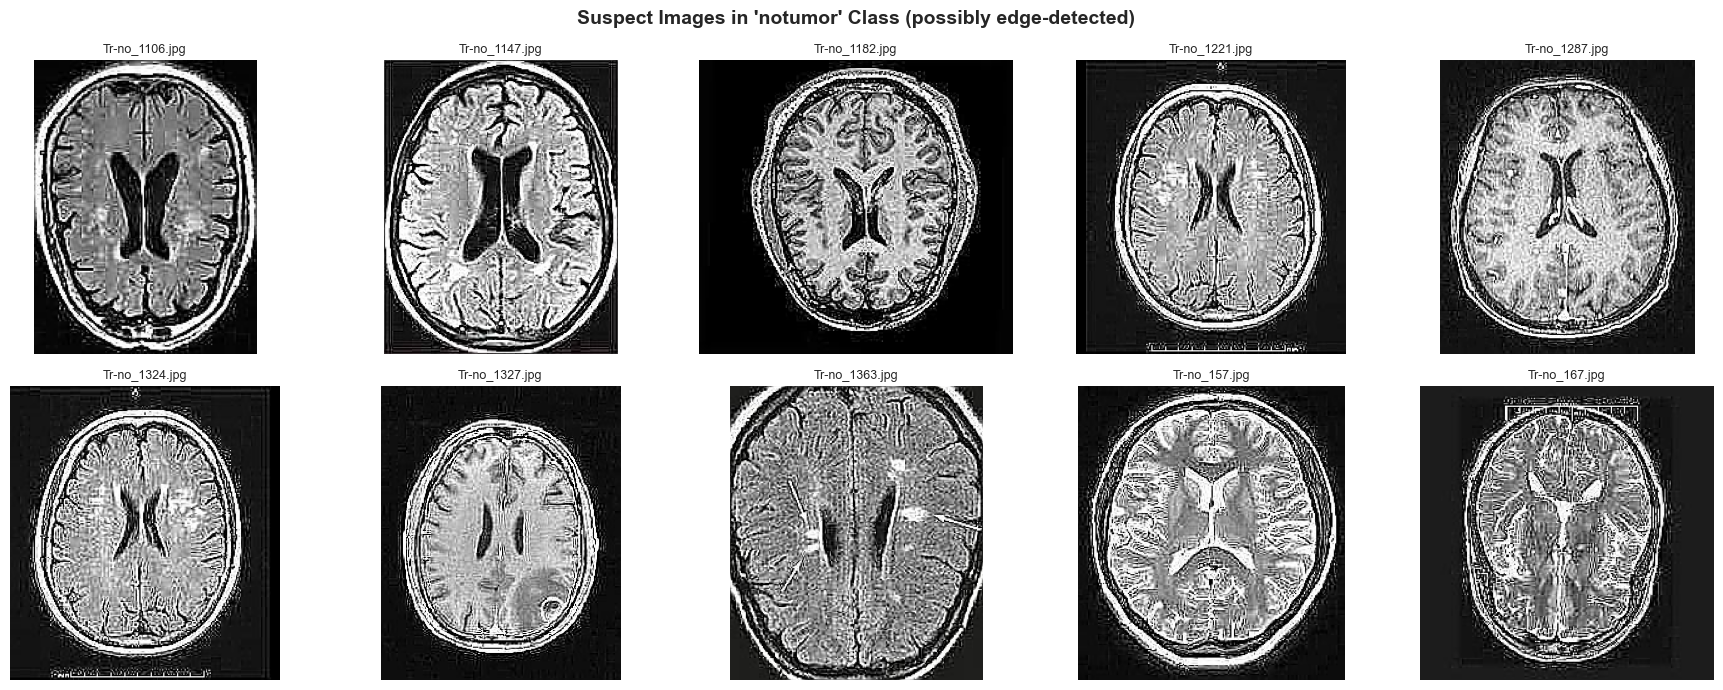

In [10]:
# Cell 9: Display suspect images
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Suspect Images in 'notumor' Class (possibly edge-detected)", fontsize=14, fontweight="bold")

for idx, img_path in enumerate(suspect_images["notumor"][:10]):
    row, col = idx // 5, idx % 5
    img = Image.open(img_path).convert("RGB")
    axes[row][col].imshow(img)
    axes[row][col].set_title(img_path.name, fontsize=9)
    axes[row][col].axis("off")

plt.tight_layout()
plt.savefig("../outputs/figures/suspect_images.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Cell 10: Check testing set for suspect images too
test_suspect = []

for cls in CLASSES:
    cls_dir = TEST_DIR / cls
    for img_path in cls_dir.iterdir():
        img = Image.open(img_path).convert("L")
        pixels = np.array(img)
        bright_ratio = np.mean(pixels > 200)
        diff = np.abs(np.diff(pixels.astype(float), axis=1))
        mean_diff = np.mean(diff)
        
        if bright_ratio > 0.15 and mean_diff > 30:
            test_suspect.append((cls, img_path))

print(f"Suspect images in Testing set: {len(test_suspect)}")
for cls, path in test_suspect:
    print(f"  {cls} → {path.name}")

Suspect images in Testing set: 0


In [12]:
# Cell 11: EDA Summary
summary = """
================================================================
EDA SUMMARY — Brain Tumor MRI Dataset
================================================================

DATASET SIZE:
  Training: 5,600 images (1,400 per class)
  Testing:  1,600 images (400 per class)
  Classes:  glioma, meningioma, notumor, pituitary

CLASS BALANCE:
  ✅ Perfectly balanced — no resampling needed

IMAGE SIZES:
  Range: 150×168 to 1375×1446
  Most images: ~512×512
  Decision: Resize all to 224×224 (standard for pretrained models)

COLOR MODES:
  RGB:  3,238  (58%)
  L:    2,358  (42%)
  RGBA: 3
  P:    1
  Decision: Convert all to RGB using .convert("RGB")

DATA QUALITY:
  Corrupted images: 0
  Suspect (edge-detected) in Training: 29 (all in 'notumor')
  Suspect in Testing: 0
  Decision: Remove 29 suspect images from training set

OBSERVATIONS:
  - Mixed scan orientations (axial, sagittal, coronal)
  - Pituitary class is mostly sagittal views
  - Glioma and meningioma may be hard to distinguish
  - Some images have text annotations burned in
  - Large black borders common — model should handle this

PREPROCESSING PLAN:
  1. Remove 29 suspect images from training
  2. Convert all images to RGB
  3. Resize to 224×224
  4. Create validation split from training data (80/20)
  5. Apply data augmentation (rotation, flip, etc.)
================================================================
"""
print(summary)

# Save the suspect image paths for removal in Phase 2
suspect_paths = [str(p) for p in suspect_images["notumor"]]
print(f"\nFiles to remove ({len(suspect_paths)}):")
for p in suspect_paths:
    print(f"  {p}")


EDA SUMMARY — Brain Tumor MRI Dataset

DATASET SIZE:
  Training: 5,600 images (1,400 per class)
  Testing:  1,600 images (400 per class)
  Classes:  glioma, meningioma, notumor, pituitary

CLASS BALANCE:
  ✅ Perfectly balanced — no resampling needed

IMAGE SIZES:
  Range: 150×168 to 1375×1446
  Most images: ~512×512
  Decision: Resize all to 224×224 (standard for pretrained models)

COLOR MODES:
  RGB:  3,238  (58%)
  L:    2,358  (42%)
  RGBA: 3
  P:    1
  Decision: Convert all to RGB using .convert("RGB")

DATA QUALITY:
  Corrupted images: 0
  Suspect (edge-detected) in Training: 29 (all in 'notumor')
  Suspect in Testing: 0
  Decision: Remove 29 suspect images from training set

OBSERVATIONS:
  - Mixed scan orientations (axial, sagittal, coronal)
  - Pituitary class is mostly sagittal views
  - Glioma and meningioma may be hard to distinguish
  - Some images have text annotations burned in
  - Large black borders common — model should handle this

PREPROCESSING PLAN:
  1. Remove 2

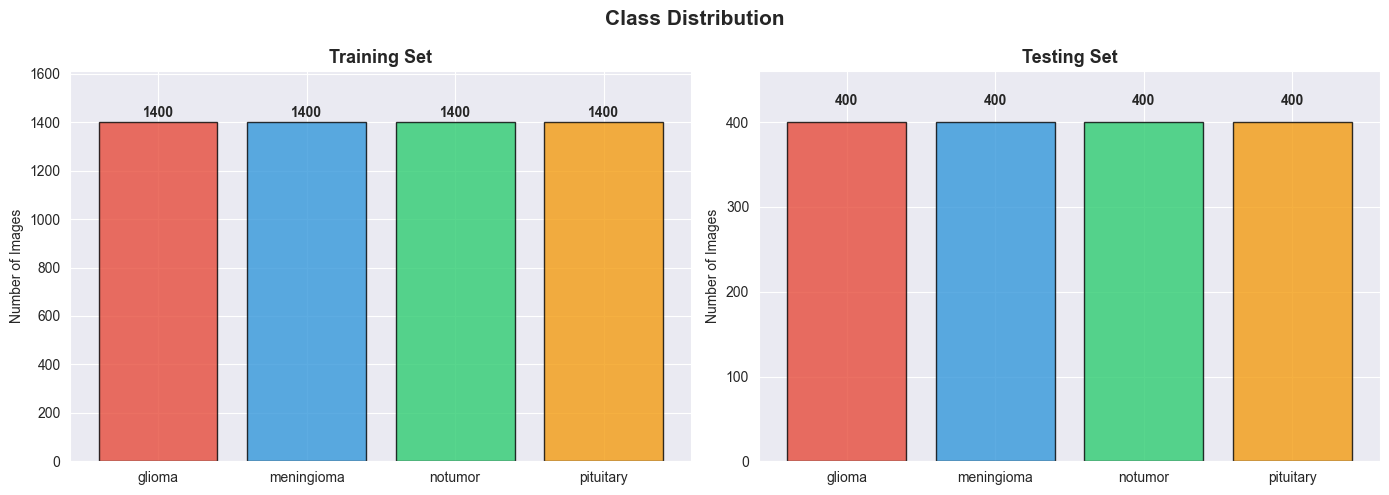

In [13]:
# Cell 12: Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (split_name, split_dir) in enumerate([("Training", TRAIN_DIR), ("Testing", TEST_DIR)]):
    counts = [len(list((split_dir / cls).iterdir())) for cls in CLASSES]
    bars = axes[idx].bar(CLASSES, counts, color=["#e74c3c", "#3498db", "#2ecc71", "#f39c12"], 
                         edgecolor="black", alpha=0.8)
    axes[idx].set_title(f"{split_name} Set", fontsize=13, fontweight="bold")
    axes[idx].set_ylabel("Number of Images")
    axes[idx].set_ylim(0, max(counts) * 1.15)
    
    for bar, count in zip(bars, counts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                      str(count), ha="center", fontweight="bold")

plt.suptitle("Class Distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

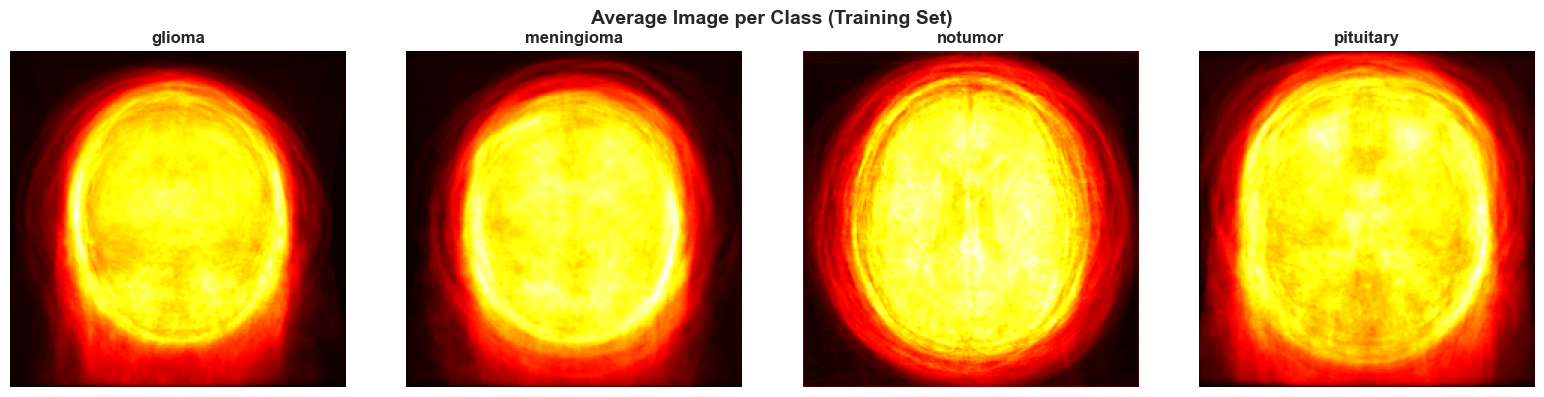

In [14]:
# Cell 13: Average pixel intensity per class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Average Image per Class (Training Set)", fontsize=14, fontweight="bold")

for idx, cls in enumerate(CLASSES):
    cls_dir = TRAIN_DIR / cls
    all_images = list(cls_dir.iterdir())
    samples = random.sample(all_images, 100)  # Average 100 random images
    
    avg_img = np.zeros((224, 224), dtype=np.float64)
    for img_path in samples:
        img = Image.open(img_path).convert("L").resize((224, 224))
        avg_img += np.array(img)
    avg_img /= len(samples)
    
    axes[idx].imshow(avg_img, cmap="hot")
    axes[idx].set_title(cls, fontsize=12, fontweight="bold")
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("../outputs/figures/average_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

In [1]:
# Cell 14: Confidence Distribution
import torch
from src.models.classifier import BrainTumorClassifier
from src.data.dataset import get_dataloaders
from src.evaluation.metrics import get_predictions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("../outputs/models/best_model.pth", map_location=device, weights_only=False)
model = BrainTumorClassifier(
    num_classes=checkpoint["num_classes"],
    backbone_name=checkpoint["backbone_name"],
)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

loaders = get_dataloaders(data_dir="../data/splits", batch_size=8, num_workers=0)
labels, preds, probs = get_predictions(model, loaders["test"], device)

# Get confidence (probability of predicted class)
confidences = [probs[i][preds[i]] for i in range(len(preds))]
correct_conf = [c for c, l, p in zip(confidences, labels, preds) if l == p]
wrong_conf = [c for c, l, p in zip(confidences, labels, preds) if l != p]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(correct_conf, bins=30, alpha=0.7, color="green", label=f"Correct ({len(correct_conf)})", edgecolor="black")
ax.hist(wrong_conf, bins=30, alpha=0.7, color="red", label=f"Wrong ({len(wrong_conf)})", edgecolor="black")
ax.set_xlabel("Confidence", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Model Confidence: Correct vs Wrong Predictions", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined